# Data Profiling — Système Intelligent de Prédiction du Risque de Diabète

**Étape 1 — Chargement et Analyse Exploratoire des Données (EDA)**

Ce notebook utilise la classe `DataProfiler` (`src/data_profiler.py`), un module **autonome** (sans dépendance à `Config`) qui prend en entrée le chemin du CSV.

Objectifs :
- Charger le dataset avec pandas
- Comprendre la structure générale (types, dimensions, aperçu)
- Identifier les valeurs manquantes et les doublons
- Repérer les zéros aberrants (valeurs manquantes déguisées)
- Analyser la distribution des variables numériques
- Visualiser les relations entre variables (pairplot, corrélations)


In [1]:
import sys
sys.path.append("..")  

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_profiler import DataProfiler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement du dataset

In [19]:
profiler = DataProfiler("../data/processed/cleaned_data_diabetes.csv")
df = profiler.load()
df.head()


,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.0,6.0,148.0,72.0,35.0,145.333333,33.6,0.627,50.0
1,1.0,1.0,85.0,66.0,29.0,107.333333,26.6,0.351,31.0
2,2.0,8.0,183.0,64.0,29.0,521.333333,23.3,0.672,32.0
3,3.0,1.0,89.0,66.0,23.0,94.000000,28.1,0.167,21.0
4,4.0,0.0,137.0,40.0,35.0,168.000000,43.1,2.288,33.0


**Note :** la colonne `Unnamed: 0` est un index résiduel du CSV (pas une variable clinique).
On l'écarte des analyses numériques ci-dessous sans modifier `profiler.df`.

## 2. Structure générale : dimensions, types, aperçu

In [20]:
info = profiler.shape_info()
print(f"Dimensions : {info['n_rows']} lignes x {info['n_cols']} colonnes")
print("\nColonnes :", info["columns"])
print("\nTypes :")
pd.Series(info["dtypes"])


Dimensions : 768 lignes x 9 colonnes

Colonnes : ['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Types :


Unnamed: 0                  float64
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
dtype: str

In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    float64
 1   Pregnancies               768 non-null    float64
 2   Glucose                   768 non-null    float64
 3   BloodPressure             768 non-null    float64
 4   SkinThickness             768 non-null    float64
 5   Insulin                   768 non-null    float64
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


## 3. Valeurs manquantes et doublons

In [22]:
print("Valeurs manquantes (NaN) par colonne :")
print(profiler.missing_values())

print(f"\nNombre de lignes dupliquées : {profiler.duplicates()}")


Valeurs manquantes (NaN) par colonne :
Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Nombre de lignes dupliquées : 0


### Zéros aberrants (valeurs manquantes déguisées)

Dans ce dataset, un `0` pour `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` ou `BMI`
est physiologiquement impossible : il s'agit très probablement de valeurs manquantes
codées en `0` plutôt qu'en `NaN`.

In [23]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zeros = profiler.zero_counts(columns=zero_cols)
zeros_pct = (zeros / len(df) * 100).round(1)

pd.DataFrame({"nb_zeros": zeros, "pct_zeros": zeros_pct})


,nb_zeros,pct_zeros
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


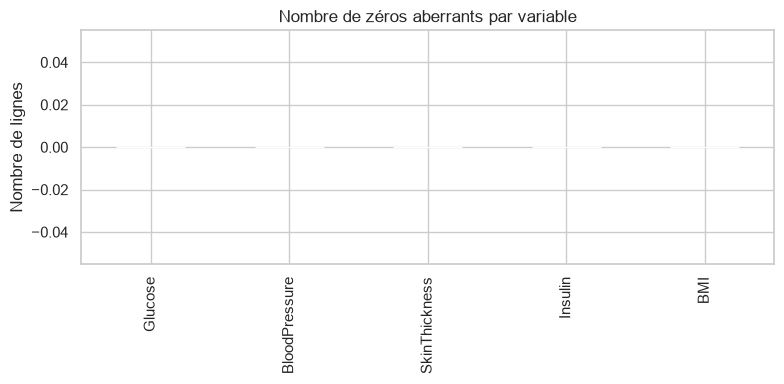

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
zeros.sort_values(ascending=False).plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Nombre de zéros aberrants par variable")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()


## 4. Distribution des variables numériques

In [25]:
profiler.numeric_distribution().loc[df.select_dtypes(include=["number"]).columns]


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,768.0,383.500000,221.846794,0.000,191.750000,383.5000,575.25000,767.00
Pregnancies,768.0,3.845052,3.369578,0.000,1.000000,3.0000,6.00000,17.00
Glucose,768.0,121.588108,30.482789,44.000,99.000000,117.0000,140.25000,199.00
BloodPressure,768.0,72.367188,12.249271,24.000,64.000000,72.0000,80.00000,122.00
SkinThickness,768.0,29.165365,9.412297,7.000,23.000000,29.0000,35.00000,99.00
Insulin,768.0,154.574219,103.318876,14.000,86.916667,130.0000,190.00000,846.00
BMI,768.0,32.423177,6.899303,18.200,27.500000,32.2500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.243750,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.000000,29.0000,41.00000,81.00


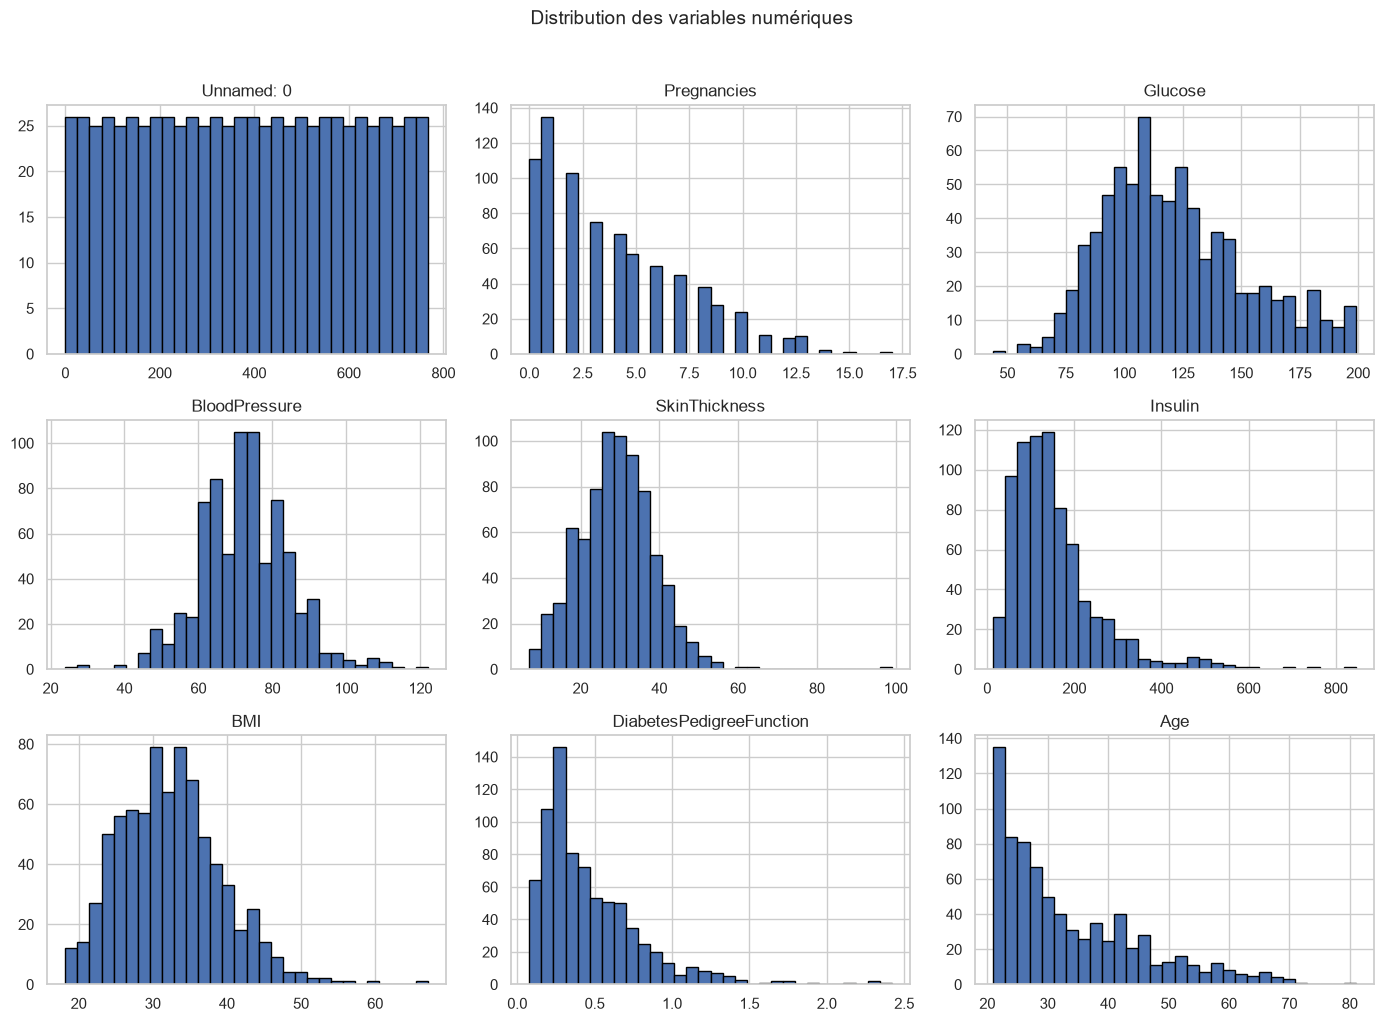

In [26]:
df[df.select_dtypes(include=["number"]).columns].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Distribution des variables numériques", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Boîtes à moustaches (détection visuelle des outliers)

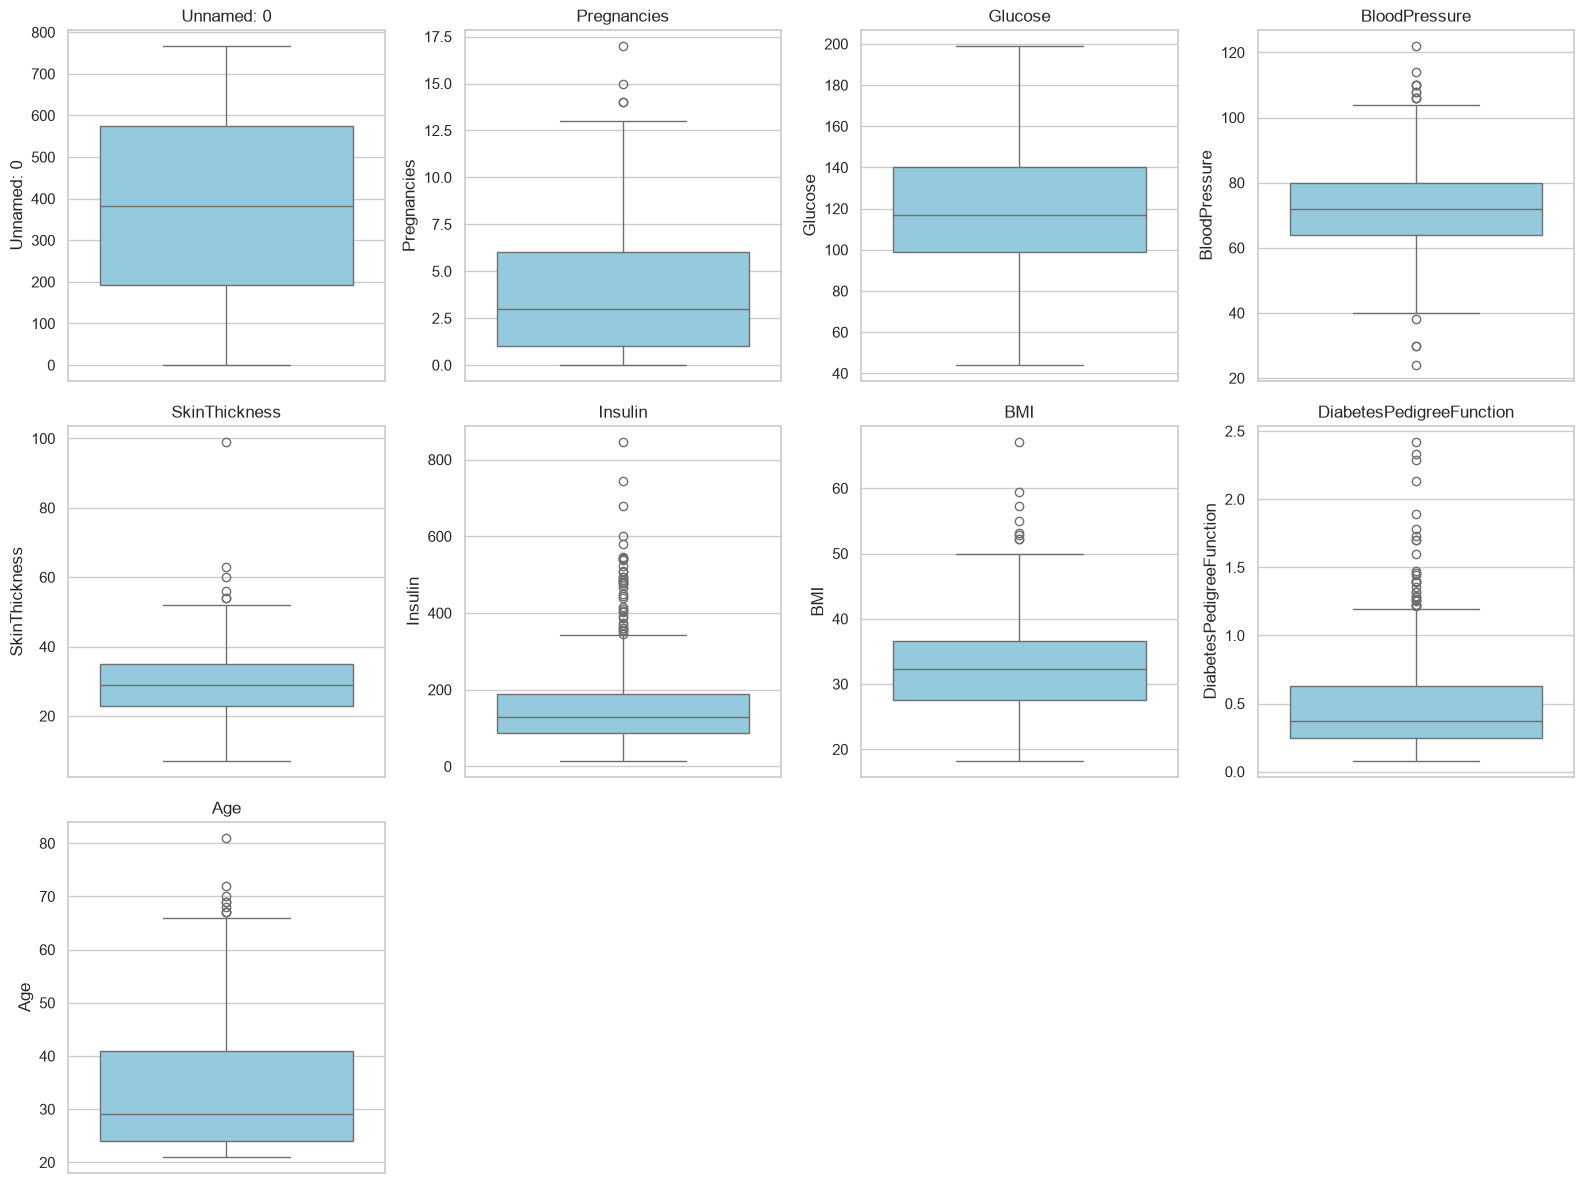

In [27]:
n_cols = 4
n_rows = -(-len(df.columns) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Outliers détectés par la méthode IQR (1.5 x IQR)

In [28]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
outliers = profiler.outlier_counts_iqr(columns=numeric_cols)
outliers.sort_values(ascending=False)
outliers.sort_values(ascending=False)


Insulin                     37
DiabetesPedigreeFunction    29
BloodPressure               14
Age                          9
BMI                          8
SkinThickness                6
Pregnancies                  4
Unnamed: 0                   0
Glucose                      0
Name: outliers_iqr, dtype: int64

## 5. Relations entre les variables

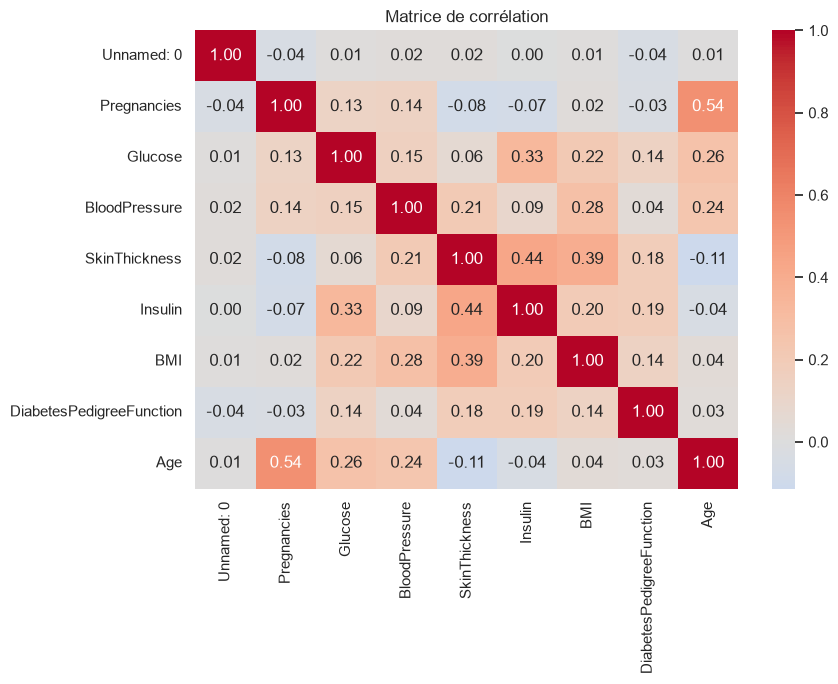

In [14]:
corr = profiler.correlations().loc[df.columns, df.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.show()


### Pairplot

Visualisation des relations deux à deux entre les variables présentant
la plus grande variabilité (utile pour préparer le choix des features
du clustering à l'étape suivante).

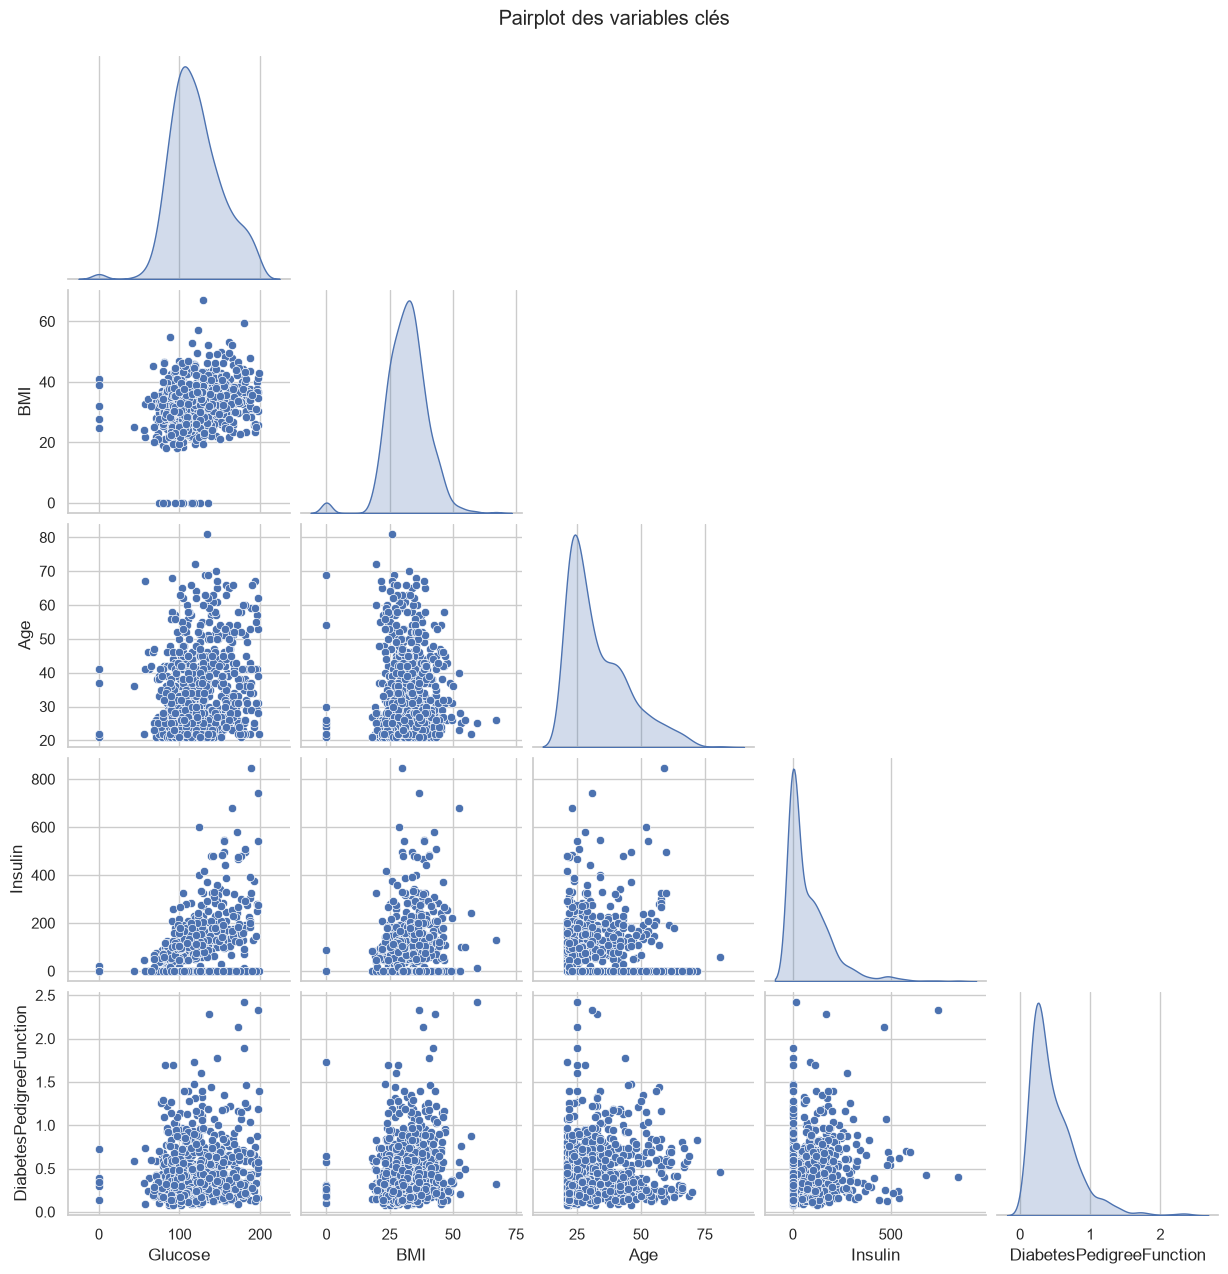

In [15]:
subset_cols = ["Glucose", "BMI", "Age", "Insulin", "DiabetesPedigreeFunction"]

sns.pairplot(df[subset_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot des variables clés", y=1.02)
plt.show()


## 6. Résumé (rapport complet)

Équivalent condensé de toutes les analyses ci-dessus, via `profiler.report()`.

In [16]:
profiler.report()


Dimensions : 768 lignes x 9 colonnes
Colonnes   : ['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Types :
Unnamed: 0                    int64
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: str

Valeurs manquantes (NaN) :
Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Doublons : 0

Zéros par colonne :
Unnamed: 0                    1
Pregnancies                 111
Glucose                       5
BloodPressure                35
Skin

## Conclusions de l'EDA

- **768 lignes, 8 variables cliniques** (après mise à l'écart de l'index parasite `Unnamed: 0`), aucun `NaN` déclaré, aucun doublon.
- Des **zéros aberrants** sont présents sur `Insulin` (~49%), `SkinThickness` (~30%), `BloodPressure` (~5%), `BMI` (~1%) et `Glucose` (~0.6%) : à traiter comme des valeurs manquantes à l'étape de prétraitement (Étape 2).
- La méthode IQR détecte des outliers notables sur `Insulin`, `DiabetesPedigreeFunction`, `BMI` et `BloodPressure`.
- `Glucose`, `BMI` et `DiabetesPedigreeFunction` sont les variables clés pour le clustering (ce sont elles qui définiront les seuils du cluster à haut risque à l'Étape 4).

**Prochaine étape :** prétraitement (imputation des zéros/`NaN`, traitement des outliers, standardisation) — voir `src/data_cleaner.py` et le notebook suivant.